In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'png'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2xlb25tYXJ0aW5fYmloL3Byb2plY3RzL1RWQi1PL3R2Yi1vbnRvbG9neS1vcHRpbS13b3Jrc2hvcC9ub3RlYm9va3M='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/_bootstrap.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/_bootstrap_external.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/zipimport.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/codecs.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/aliases.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/__init__.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/utf_8.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks

In [2]:
#| output: false
import os
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = "../img/section-1"
DPI = 200
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name, **kw):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=DPI, bbox_inches="tight", **kw)
    print(f"saved → {path}")

In [3]:
#| output: false
import networkx as nx
from matplotlib.lines import Line2D

cividis = plt.get_cmap("cividis")
c_node     = cividis(0.65)
c_affected = cividis(0.88)
c_lesion   = "#c62828"
c_edge     = "#9e9e9e"
c_edge_cut = "#c62828"

# Shared node positions — identical between the two panels by design.
positions = {
    0: ( 0.00,  0.00),   # the lesioned node (same in both panels)
    1: ( 1.20,  0.40),
    2: ( 1.30, -0.55),
    3: (-1.10,  0.55),
    4: (-1.30, -0.40),
    5: ( 0.50,  1.20),
    6: (-0.55, -1.20),
    7: ( 2.00,  1.10),
    8: (-2.00, -0.95),
    9: ( 1.00, -1.50),
}

def make_hub():
    """Patient A: lesion node 0 sits at a hub (degree 6)."""
    G = nx.Graph()
    G.add_nodes_from(range(10))
    G.add_edges_from([
        (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6),
        (1, 7), (2, 9), (3, 8), (4, 8), (5, 7), (6, 9),
        (1, 2),
    ])
    return G

def make_periphery():
    """Patient B: lesion node 0 sits at the periphery (degree 1)."""
    G = nx.Graph()
    G.add_nodes_from(range(10))
    G.add_edges_from([
        (0, 1),
        (1, 2), (1, 3), (2, 3), (2, 5), (3, 4),
        (4, 5), (4, 6), (5, 7), (6, 8), (7, 8),
        (7, 9), (8, 9),
    ])
    return G

def draw_panel(ax, G, title, lesion=0):
    affected = set(G.neighbors(lesion))

    for (u, v) in G.edges():
        cut = (u == lesion or v == lesion)
        x = [positions[u][0], positions[v][0]]
        y = [positions[u][1], positions[v][1]]
        ax.plot(
            x, y,
            color=c_edge_cut if cut else c_edge,
            linestyle="--" if cut else "-",
            linewidth=2.0 if cut else 1.6,
            alpha=0.85 if cut else 0.7,
            zorder=1,
        )

    for n, (x, y) in positions.items():
        if n == lesion:
            continue
        in_deficit = n in affected
        ax.scatter(
            [x], [y],
            s=620,
            color=c_affected if in_deficit else c_node,
            edgecolors=c_lesion if in_deficit else "black",
            linewidths=2.0 if in_deficit else 1.2,
            zorder=3,
        )

    lx, ly = positions[lesion]
    ax.scatter([lx], [ly], s=720, marker="X",
               color=c_lesion, edgecolors="black", linewidths=1.6, zorder=4)

    deg = G.degree(lesion)
    ax.set_title(f"{title}\nlesion degree = {deg}", fontsize=13)
    ax.set_xlim(-2.6, 2.6)
    ax.set_ylim(-2.0, 1.7)
    ax.set_aspect("equal")
    ax.axis("off")

saved → ../img/section-1/lesion_network.png


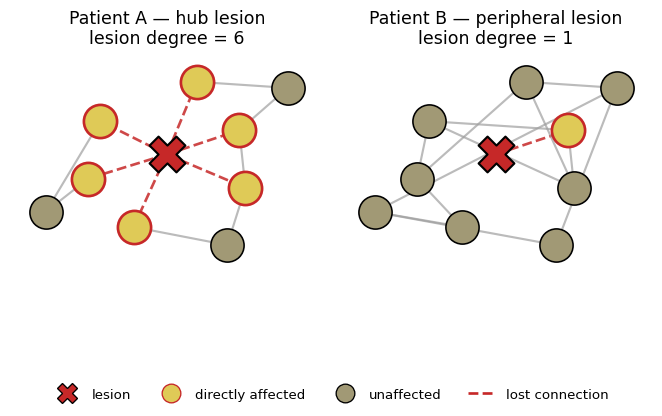

In [4]:
#| label: fig-lesion-network
#| fig-cap: 'Same lesion (red ✕), same physical location, same surrounding nodes — but the *connectivity* differs. Left: a hub lesion knocks out six direct connections; the deficit territory (red-rimmed) covers most of the network. Right: the same lesion at a peripheral node touches one neighbour and the rest of the network is untouched.'

fig, axes = plt.subplots(1, 2, figsize=(7.0, 5.0))
draw_panel(axes[0], make_hub(),       "Patient A — hub lesion")
draw_panel(axes[1], make_periphery(), "Patient B — peripheral lesion")

handles = [
    Line2D([0], [0], marker="X", color="w", markerfacecolor=c_lesion,
           markeredgecolor="black", markersize=15, label="lesion"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c_affected,
           markeredgecolor=c_lesion, markersize=14, label="directly affected"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c_node,
           markeredgecolor="black", markersize=14, label="unaffected"),
    Line2D([0], [0], color=c_edge_cut, linestyle="--", linewidth=2.0,
           label="lost connection"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
savefig("lesion_network.png")
plt.show()

In [5]:
#| output: false
from scipy.ndimage import gaussian_filter1d

rng = np.random.default_rng(7)

# --- module assignment ----------------------------------------------------
modules = [
    ("module 1", [0, 1, 2]),
    ("module 2", [3, 4, 5]),
    ("module 3", [6, 7]),
]
n_regions = sum(len(idx) for _, idx in modules)
region_to_module = {r: m for m, (_, idx) in enumerate(modules) for r in idx}

cividis = plt.get_cmap("cividis")
module_colors = [cividis(0.20), cividis(0.55), cividis(0.85)]

# --- synthetic resting-state-like signals ---------------------------------
fs = 10.0                   # samples per second
T = 60.0                    # seconds
n_t = int(fs * T)
t = np.arange(n_t) / fs

def slow_latent(seed):
    """Smooth low-frequency latent: filtered noise."""
    raw = rng.standard_normal(n_t)
    return gaussian_filter1d(raw, sigma=fs * 1.5)   # ~0.1 Hz

latents = np.stack([slow_latent(m) for m in range(len(modules))])

signals = np.zeros((n_regions, n_t))
for r in range(n_regions):
    m = region_to_module[r]
    shared = latents[m]
    idiosyncratic = gaussian_filter1d(rng.standard_normal(n_t), sigma=fs * 0.4)
    s = 1.0 * shared + 0.20 * idiosyncratic
    signals[r] = (s - s.mean()) / s.std()

# --- functional connectivity ---------------------------------------------
fc = np.corrcoef(signals)

saved → ../img/section-1/rest_structured.png


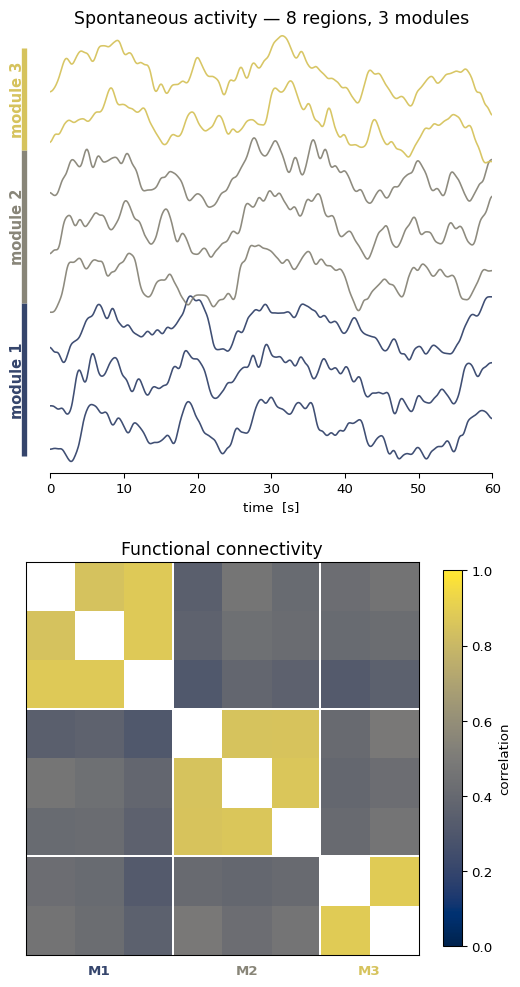

In [6]:
#| label: fig-rest-structured
#| fig-cap: 'Synthetic resting activity for 8 regions in 3 modules. Left: stacked traces over 60 s — within-module signals wiggle together (shared slow latent), across modules they are decoupled. Right: the resulting functional-connectivity matrix shows three blocks along the diagonal. Same idea as empirical resting-state networks: spontaneous activity already carries structure.'

fig, (ax_t, ax_fc) = plt.subplots(
    2, 1, figsize=(5.5, 10.5), gridspec_kw={"height_ratios": [1.0, 1.0]}
)
ax_t.set_box_aspect(1)
ax_fc.set_box_aspect(1)

# --- traces panel ---------------------------------------------------------
offset_step = 3.0
for r in range(n_regions):
    m = region_to_module[r]
    ax_t.plot(t, signals[r] + r * offset_step,
              color=module_colors[m], lw=1.2, alpha=0.95)

# module brackets on the left
for m_idx, (label, regs) in enumerate(modules):
    y_lo = regs[0] * offset_step - 1.5
    y_hi = regs[-1] * offset_step + 1.5
    ax_t.plot([-3.5, -3.5], [y_lo, y_hi],
              color=module_colors[m_idx], lw=4, solid_capstyle="butt",
              clip_on=False)
    ax_t.text(-4.5, (y_lo + y_hi) / 2, label,
              rotation=90, ha="center", va="center",
              color=module_colors[m_idx], fontsize=11, fontweight="bold")

ax_t.set_xlim(0, T)
ax_t.set_ylim(-2.5, n_regions * offset_step - 0.5)
ax_t.set_xlabel("time  [s]")
ax_t.set_yticks([])
ax_t.set_title("Spontaneous activity — 8 regions, 3 modules", fontsize=13)
for spine in ("top", "right", "left"):
    ax_t.spines[spine].set_visible(False)

# --- FC panel -------------------------------------------------------------
fc_show = fc.copy()
np.fill_diagonal(fc_show, np.nan)
im = ax_fc.imshow(fc_show, cmap="cividis", vmin=0, vmax=1)
ax_fc.set_title("Functional connectivity", fontsize=13)
ax_fc.set_xticks([]); ax_fc.set_yticks([])

# module dividers
boundaries = np.cumsum([len(idx) for _, idx in modules])[:-1] - 0.5
for b in boundaries:
    ax_fc.axhline(b, color="white", lw=1.5)
    ax_fc.axvline(b, color="white", lw=1.5)

# module labels along the FC axes
starts = [0] + list(np.cumsum([len(idx) for _, idx in modules])[:-1])
ends   = list(np.cumsum([len(idx) for _, idx in modules]))
for m_idx, (start, end) in enumerate(zip(starts, ends)):
    mid = (start + end - 1) / 2
    ax_fc.text(mid, n_regions - 0.3, f"M{m_idx + 1}",
               ha="center", va="top",
               color=module_colors[m_idx], fontsize=10, fontweight="bold",
               transform=ax_fc.transData)

plt.colorbar(im, ax=ax_fc, shrink=0.85, label="correlation")

plt.tight_layout()
savefig("rest_structured.png")
plt.show()

In [7]:
#| output: false
from scipy.special import gamma as gamma_func

rng = np.random.default_rng(13)

fs = 200.0
T = 20.0
n_t = int(fs * T)
t_obs = np.arange(n_t) / fs

# --- shared underlying slow envelope (the network "state") ----------------
slow_env = gaussian_filter1d(rng.standard_normal(n_t), sigma=fs * 1.5)
slow_env = (slow_env - slow_env.mean()) / (slow_env.std() + 1e-9)

# --- EEG / MEG: ~8 Hz alpha, modulated by the slow envelope ---------------
eeg_osc = np.sin(2 * np.pi * 8 * t_obs) * (1.0 + 0.4 * slow_env)
eeg_noise = gaussian_filter1d(rng.standard_normal(n_t), sigma=2)
eeg = eeg_osc + 0.20 * eeg_noise

# --- SEEG / iEEG: ~15 Hz beta + a few sharp transients --------------------
seeg_osc = np.sin(2 * np.pi * 15 * t_obs) * (1.0 + 0.3 * slow_env)
seeg_noise = gaussian_filter1d(rng.standard_normal(n_t), sigma=1)
seeg = 0.7 * seeg_osc + 0.30 * seeg_noise
for ts in [4.5, 11.2, 16.8]:
    idx = int(ts * fs)
    width = int(0.15 * fs)
    if idx + width < n_t:
        seeg[idx:idx + 5] += np.linspace(1.5, 4.5, 5)
        seeg[idx + 5:idx + width] += 4.5 * np.exp(
            -np.arange(width - 5) / (0.03 * fs)
        )

# --- fMRI BOLD: slow envelope convolved with canonical HRF ----------------
# HRF kernel must be shorter than the signal so np.convolve(mode="same")
# returns the signal length, not the kernel length.
t_hrf = np.arange(0, 15, 1 / fs)
hrf_k = ((t_hrf ** 5 * np.exp(-t_hrf)) / gamma_func(6)
         - (1 / 6) * (t_hrf ** 15 * np.exp(-t_hrf)) / gamma_func(16))
hrf_k = hrf_k / hrf_k.max()
bold = np.convolve(slow_env, hrf_k, mode="same")
bold = (bold - bold.mean()) / (bold.std() + 1e-9)

saved → ../img/section-1/observables_multimodal.png


/var/folders/ym/9kw1g21j1nd7kwfn8c0z3st40000gn/T/ipykernel_3020/1591279614.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


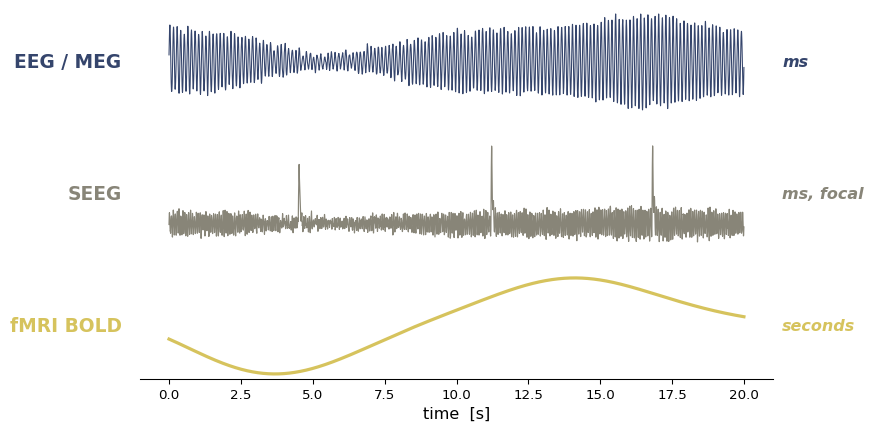

In [8]:
#| label: fig-observables
#| fig-cap: 'One simulated state, three observables. Top: EEG/MEG fast oscillations (ms). Middle: SEEG with sharp transients (ms, focal). Bottom: BOLD, the slow envelope through the canonical HRF (seconds).'

cividis = plt.get_cmap("cividis")
mod_colors = [cividis(0.20), cividis(0.55), cividis(0.85)]

modalities = [
    ("EEG / MEG",   eeg,  "ms",      mod_colors[0], 0.8),
    ("SEEG",        seeg, "ms, focal", mod_colors[1], 0.9),
    ("fMRI BOLD",   bold, "seconds", mod_colors[2], 2.4),
]

fig, axes = plt.subplots(
    3, 1, figsize=(8.5, 5.0), sharex=True,
    gridspec_kw={"hspace": 0.25},
)

for ax, (name, sig, scale, color, lw) in zip(axes, modalities):
    ax.plot(t_obs, sig, color=color, lw=lw)
    ax.set_ylabel(name, fontsize=14, fontweight="bold",
                  rotation=0, ha="right", va="center", labelpad=14,
                  color=color)
    ax.text(1.015, 0.5, scale, transform=ax.transAxes,
            ha="left", va="center", fontsize=12,
            color=color, style="italic", fontweight="bold")
    ax.set_yticks([])
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)

for ax in axes[:-1]:
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis="x", which="both", length=0)
axes[-1].set_xlabel("time  [s]", fontsize=12)

plt.tight_layout()
savefig("observables_multimodal.png")
plt.show()

saved → ../img/section-1/tvb_history_timeline.png


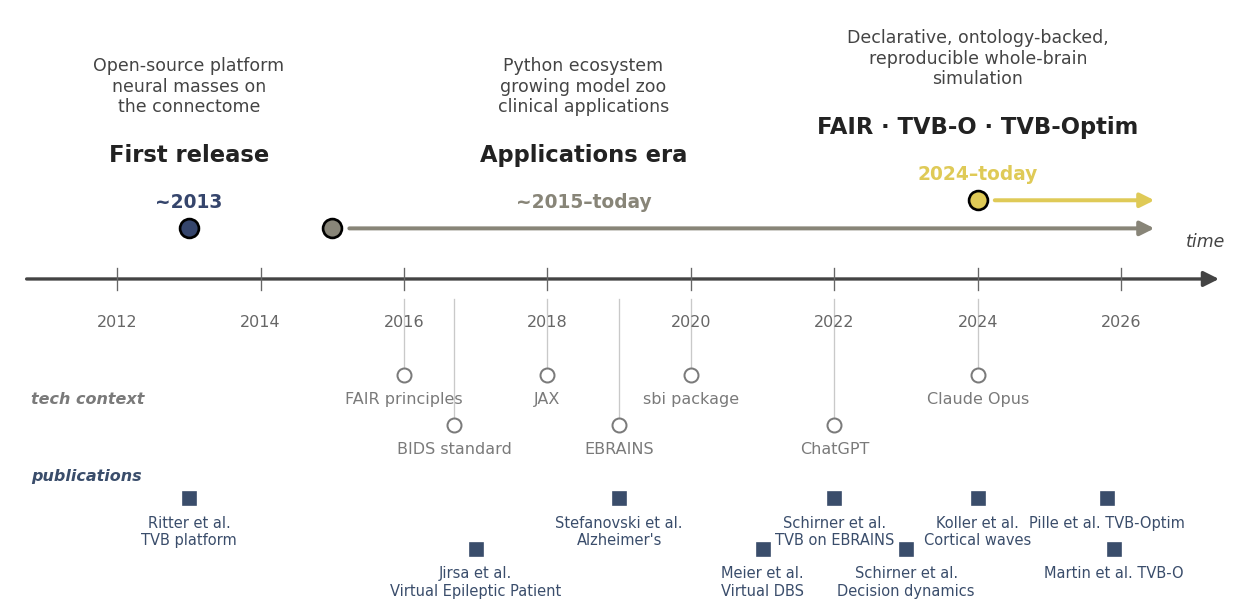

In [9]:
#| label: fig-tvb-history
#| fig-cap: Three eras of TVB on a single time arrow. Marker colour walks the cividis ramp from past to present.

from matplotlib.patches import FancyArrowPatch

cividis = plt.get_cmap("cividis")
colors = [cividis(0.20), cividis(0.55), cividis(0.88)]

milestones = [
    dict(
        x_start=2013, x_end=2013, y=0.45,
        year="~2013",
        title="First release",
        subtitle="Open-source platform\nneural masses on\nthe connectome",
        color=colors[0],
    ),
    dict(
        x_start=2015, x_end=2026.5, x_label=2018.5, y=0.45,
        year="~2015–today",
        title="Applications era",
        subtitle="Python ecosystem\ngrowing model zoo\nclinical applications",
        color=colors[1],
    ),
    dict(
        x_start=2024, x_end=2026.5, y=0.70,
        year="2024–today",
        title="FAIR · TVB-O · TVB-Optim",
        subtitle="Declarative, ontology-backed,\nreproducible whole-brain\nsimulation",
        color=colors[2],
    ),
]

fig, ax = plt.subplots(figsize=(13.0, 6.5))

x_lo, x_hi = 2010.5, 2027.5
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(-2.85, 2.4)
ax.axis("off")

# time arrow
arrow = FancyArrowPatch(
    (x_lo + 0.2, 0), (x_hi - 0.1, 0),
    arrowstyle="-|>", mutation_scale=24,
    color="#444", lw=2.5, zorder=2,
)
ax.add_patch(arrow)

# year ticks under the arrow
for yr in range(2012, 2027, 2):
    ax.plot([yr, yr], [-0.10, 0.10], color="#666", lw=1.0, zorder=2)
    ax.text(yr, -0.32, str(yr),
            ha="center", va="top", fontsize=12, color="#666")

# milestones — each era starts at a dot and extends as a coloured arrow
# along its actual span. Eras 2 and 3 sit on different y-rows because they
# overlap chronologically (both extend to "today").
for m in milestones:
    y = m["y"]
    # start dot
    ax.scatter([m["x_start"]], [y], s=200, color=m["color"],
               edgecolors="black", linewidths=2, zorder=5)
    # era arrow (only for ranges, not for point events)
    if m["x_end"] > m["x_start"] + 0.5:
        ax.add_patch(FancyArrowPatch(
            (m["x_start"] + 0.20, y), (m["x_end"], y),
            arrowstyle="-|>", mutation_scale=22,
            color=m["color"], lw=3.0, zorder=4,
        ))
    # label block above the dot (shifted to x_label if set, to avoid overlaps)
    x_label = m.get("x_label", m["x_start"])
    ax.text(x_label, y + 0.15, m["year"],
            ha="center", va="bottom",
            fontsize=14, fontweight="bold", color=m["color"])
    ax.text(x_label, y + 0.55, m["title"],
            ha="center", va="bottom",
            fontsize=17, fontweight="bold", color="#222")
    ax.text(x_label, y + 1.00, m["subtitle"],
            ha="center", va="bottom",
            fontsize=13, color="#444")

# "time" label at the end of the arrow
ax.text(x_hi - 0.05, 0.25, "time",
        ha="right", va="bottom", fontsize=13,
        color="#444", style="italic")

# --- tech context band (below the arrow) ----------------------------------
# Background events that shaped the tooling brain network models now lean on:
# autodiff frameworks (JAX powers tvboptim), and the broader AI moment.
tech_color = "#7a7a7a"
tech_events = [
    dict(x=2016.0, label="FAIR principles", row=0),
    dict(x=2016.7, label="BIDS standard",   row=1),
    dict(x=2018, label="JAX",             row=0),
    dict(x=2019, label="EBRAINS",         row=1),
    dict(x=2020, label="sbi package",     row=0),
    dict(x=2022, label="ChatGPT",         row=1),
    dict(x=2024, label="Claude Opus",     row=0),
]

row_y_marker = {0: -0.85, 1: -1.30}
row_y_label  = {0: -1.00, 1: -1.45}

# row label on the far left
ax.text(x_lo + 0.3, -1.07, "tech context",
        ha="left", va="center",
        fontsize=12, color=tech_color, style="italic", fontweight="bold")

for t in tech_events:
    ym = row_y_marker[t["row"]]
    yl = row_y_label[t["row"]]
    # short connector from arrow base down to marker
    ax.plot([t["x"], t["x"]], [-0.18, ym + 0.06],
            color=tech_color, lw=1.0, alpha=0.4, zorder=3)
    # marker
    ax.scatter([t["x"]], [ym], s=110,
               color="white", edgecolors=tech_color,
               linewidths=1.5, zorder=5)
    # label
    ax.text(t["x"], yl, t["label"],
            ha="center", va="top",
            fontsize=12, color=tech_color)

# --- landmark TVB studies band (further below the tech band) --------------
# Concrete TVB-driven results that the era bubbles refer to in the abstract.
study_color = "#3a4d6b"
study_y_marker = {0: -1.95, 1: -2.40}
study_y_label  = {0: -2.10, 1: -2.55}

studies = [
    dict(x=2013,   label="Ritter et al.\nTVB platform",             row=0),
    dict(x=2017,   label="Jirsa et al.\nVirtual Epileptic Patient", row=1),
    dict(x=2019,   label="Stefanovski et al.\nAlzheimer's",         row=0),
    dict(x=2021,   label="Meier et al.\nVirtual DBS",                      row=1),
    dict(x=2022,   label="Schirner et al.\nTVB on EBRAINS",         row=0),
    dict(x=2023,   label="Schirner et al.\nDecision dynamics",      row=1),
    dict(x=2024,   label="Koller et al.\nCortical waves",           row=0),
    dict(x=2025.9, label="Martin et al. TVB-O",                    row=1),
    dict(x=2025.8, label="Pille et al. TVB-Optim",                 row=0),
]

ax.text(x_lo + 0.3, -1.75, "publications",
        ha="left", va="center",
        fontsize=12, color=study_color, style="italic", fontweight="bold")

for s in studies:
    ym = study_y_marker[s["row"]]
    yl = study_y_label[s["row"]]
    ax.scatter([s["x"]], [ym], s=140,
               color=study_color, edgecolors="white",
               linewidths=1.0, zorder=5, marker="s")
    ax.text(s["x"], yl, s["label"],
            ha="center", va="top",
            fontsize=11, color=study_color)

plt.tight_layout()
savefig("tvb_history_timeline.png")
plt.show()